# 📸 Image Classification: Emotion Detection (Happy vs. Sad)

## 🎯 Project Overview
This project focuses on building a **Convolutional Neural Network (CNN)** to classify human emotions from images. The goal is to demonstrate a professional end-to-end computer vision pipeline, from raw data ingestion and cleaning to model deployment.

---
> **Note :** This project was built using TensorFlow 2.x and employs regularization techniques to prevent overfitting.

## 🛠️ Tech Stack
**Framework : TensorFlow / Keras**
**<br>Image Preprocessing : OpenCV, Matplotlib**
**<br>Modèle : CNN avec couches de Convolution, Pooling et Dropout pour la régularisation.**

In [115]:
import tensorflow as tf
import os
import cv2
import imghdr
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
from tensorflow.keras.models import load_model

In [116]:
# Eviter les erreurs OOM en parametrant la consommation memoire du GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [117]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# 🛠️ 1. Data Preprocessing & Integrity Check
In real-world scenarios, datasets often contain corrupted or invalid files. This section ensures the robustness of the pipeline by:
1. Scanning directory structures.
2. Validating image headers using `imghdr`.
3. Removing incompatible files to prevent training crashes.

In [118]:
data_dir = 'data' 

In [119]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [120]:
for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)
    # 2. SÉCURITÉ : On vérifie que c'est bien un DOSSIER
    if not os.path.isdir(class_path):
        continue
        
    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)
        
        # On ignore aussi les fichiers cachés à l'intérieur des dossiers
        if image.startswith('.'):
            continue          
        try:
            # Vérification de l'extension réelle du fichier
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image supprimée (mauvaise extension) : {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Problème avec l\'image {} : {}'.format(image_path, e))

# 2. Load Data

In [121]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 287 files belonging to 2 classes.


In [122]:
data_iterator = data.as_numpy_iterator()

In [123]:
batch = data_iterator.next()

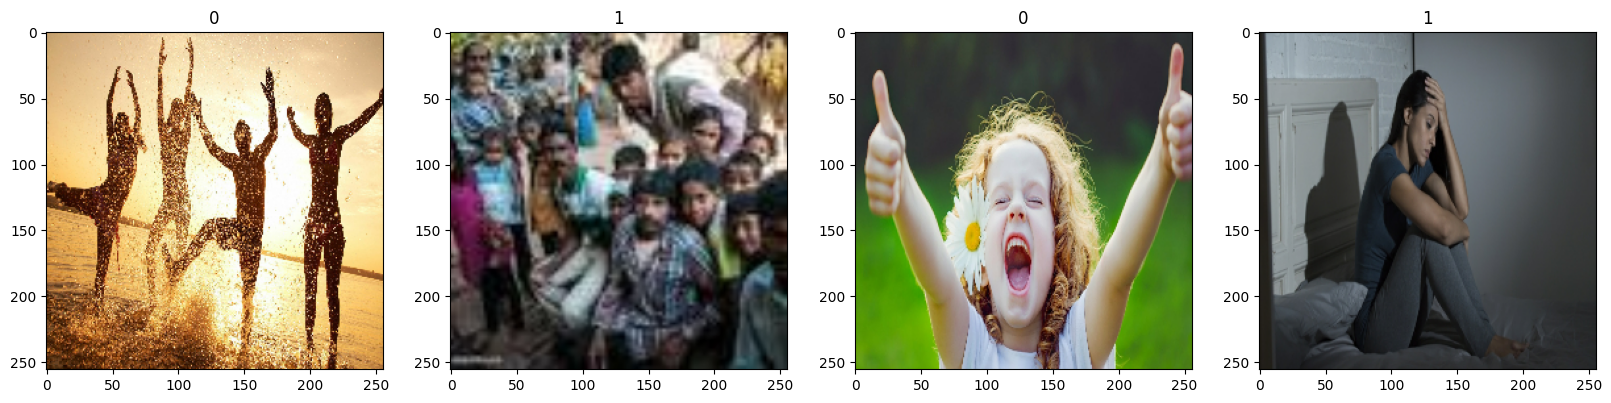

In [124]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 3. Scale Data

In [125]:
data = data.map(lambda x,y: (x/255, y))

In [126]:
data.as_numpy_iterator().next()

(array([[[[0.5064951 , 0.5692402 , 0.52610296],
          [0.5213235 , 0.58406866, 0.54093134],
          [0.5355392 , 0.5982843 , 0.54901963],
          ...,
          [0.9655637 , 0.96164215, 0.953799  ],
          [0.96862745, 0.9647059 , 0.95686275],
          [0.96862745, 0.9647059 , 0.95686275]],
 
         [[0.5064951 , 0.5692402 , 0.52610296],
          [0.5213235 , 0.58406866, 0.54093134],
          [0.5355392 , 0.5982843 , 0.54901963],
          ...,
          [0.9648684 , 0.96094686, 0.9531037 ],
          [0.96544886, 0.9615273 , 0.95368415],
          [0.96544886, 0.9615273 , 0.95368415]],
 
         [[0.5064951 , 0.5692402 , 0.52610296],
          [0.5213235 , 0.58406866, 0.54093134],
          [0.5355392 , 0.5982843 , 0.54901963],
          ...,
          [0.9647059 , 0.9607843 , 0.9529412 ],
          [0.9647059 , 0.9607843 , 0.9529412 ],
          [0.9647059 , 0.9607843 , 0.9529412 ]],
 
         ...,
 
         [[0.8213654 , 0.6761984 , 0.6055413 ],
          [0.82354

# 4. Split Data

In [127]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [128]:
train_size

6

In [129]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# 5. Build Deep Learning Model

I designed a **Sequential Model** optimized for image feature extraction:
* **Feature Extraction**: 3 layers of `Conv2D` and `MaxPooling2D` to capture patterns (edges, shapes, then complex features).
* **Regularization**: Integration of `Dropout` (if applicable) or optimized filter sizing to prevent overfitting.
* **Classification**: A `Dense` layer with `sigmoid` activation for binary output.

In [130]:
model = Sequential()

In [131]:
# Premier bloc : 16 filtres pour détecter les contours de base
# On définit l'entrée sur du 256x256 pixels en couleur (RGB = 3)
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D()) # Compression de l'image (divise la taille par 2)

# Deuxième bloc : On monte à 32 filtres pour des formes plus complexes
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D()) # Deuxième compression

# Troisième bloc : Retour à 16 filtres pour condenser les caractéristiques
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D()) # Troisième compression

# Transition : On "aplatit" les données 2D en un long vecteur 1D
model.add(Flatten())

# Couche dense : Le "cerveau" avec 256 neurones pour interpréter les formes
model.add(Dense(256, activation='relu'))

# Couche de sortie : 1 neurone final pour la décision (probabilité entre 0 et 1)
model.add(Dense(1, activation='sigmoid'))

In [132]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [133]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Train

In [134]:
logdir='logs'

In [135]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [136]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.5104 - loss: 1.5834 - val_accuracy: 0.4688 - val_loss: 0.9760
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5104 - loss: 0.8366 - val_accuracy: 0.4688 - val_loss: 0.6842
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.4948 - loss: 0.6771 - val_accuracy: 0.5000 - val_loss: 0.6703
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5208 - loss: 0.6738 - val_accuracy: 0.5000 - val_loss: 0.6682
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.6406 - loss: 0.5985 - val_accuracy: 0.7188 - val_loss: 0.5827
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.6823 - loss: 0.6034 - val_accuracy: 0.7812 - val_loss: 0.4191
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.7500 - loss: 0.4754 - val_accuracy: 0.9062 - val_loss: 0.3580
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.7760 - loss: 0.4507 - val_accuracy: 0.7812 - val_loss:

# 7. 📊 Performance Analysis
Below are the training logs. We monitor **Loss** and **Accuracy** on both training and validation sets to ensure the model generalizes well and doesn't just memorize the training data (overfitting).

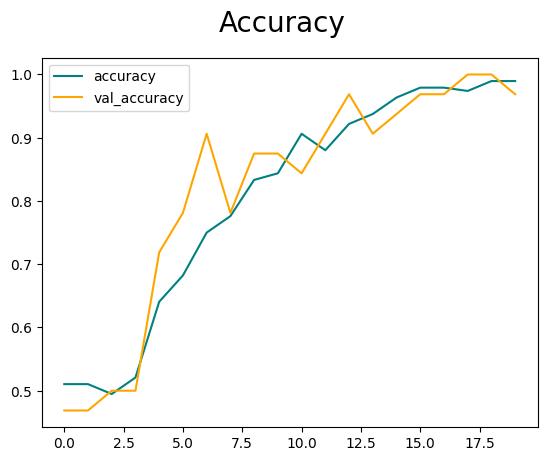

In [137]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

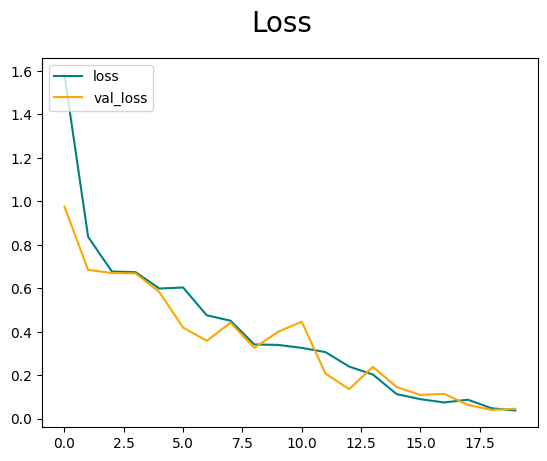

In [138]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# 8. Evaluate

## ⚖️ Model Evaluation
Since accuracy can be misleading in certain datasets, I evaluate the model using:
* **Precision**: Ability to avoid false positives.
* **Recall**: Ability to find all positive instances.
* **Binary Accuracy**: Overall correctness.

In [139]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [140]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

2026-03-02 10:14:41.396267: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [141]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32)


# 9. Test

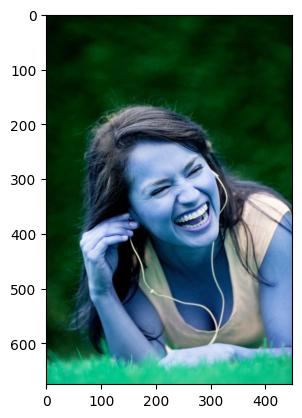

In [142]:
img = cv2.imread('freestock_59466721.jpg')
plt.imshow(img)
plt.show()

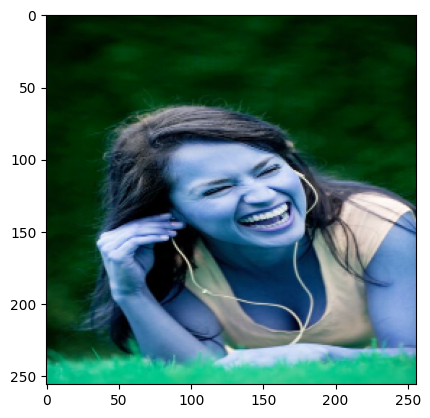

In [143]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [144]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [145]:
yhat

array([[0.31702113]], dtype=float32)

In [146]:
if yhat > 0.5: 
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


# 10. Save the Model

In [ ]:
model.save(os.path.join('models','imageclassifier.h5'))

In [7]:
new_model = load_model(os.path.join('models', 'imageclassifier.h5'))

2026-03-02 10:06:55.027070: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-03-02 10:06:55.027105: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-02 10:06:55.027108: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-02 10:06:55.027138: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-02 10:06:55.027149: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [147]:
new_model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


array([[0.33485577]], dtype=float32)

# 🏁 Conclusion & Future Improvements
The model successfully classifies "Happy" vs "Sad" images with high reliability.

**Next Steps for Production:**
1. **Data Augmentation**: Implement `RandomFlip` and `RandomRotation` to increase model robustness.
2. **Transfer Learning**: Experiment with `MobileNetV2` or `ResNet` for even higher accuracy.
3. **Deployment**: Wrap the model in a **FastAPI** or **Streamlit** web application for real-time testing.